# dSprites EDA: Understanding Factors and Splits

In [46]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

from src.datasets.dsprites import load_dsprites, get_factor_names, make_iid_split
from src.datasets.correlated_dsprites import make_correlated_split, make_heldout_pair_split, factor_pair_table

dataset = load_dsprites()
print(f'Loaded {len(dataset["imgs"])} images')

Loaded 737280 images


## Dataset Summary

In [47]:
factor_names = get_factor_names()
print(f'Shape: {dataset["imgs"].shape}')
print(f'Total: {len(dataset["imgs"]):,}')
print(f'Factors: {factor_names}')

Shape: (737280, 64, 64)
Total: 737,280
Factors: ['color', 'shape', 'scale', 'orientation', 'pos_x', 'pos_y']


## Random Image Grid (5x5)

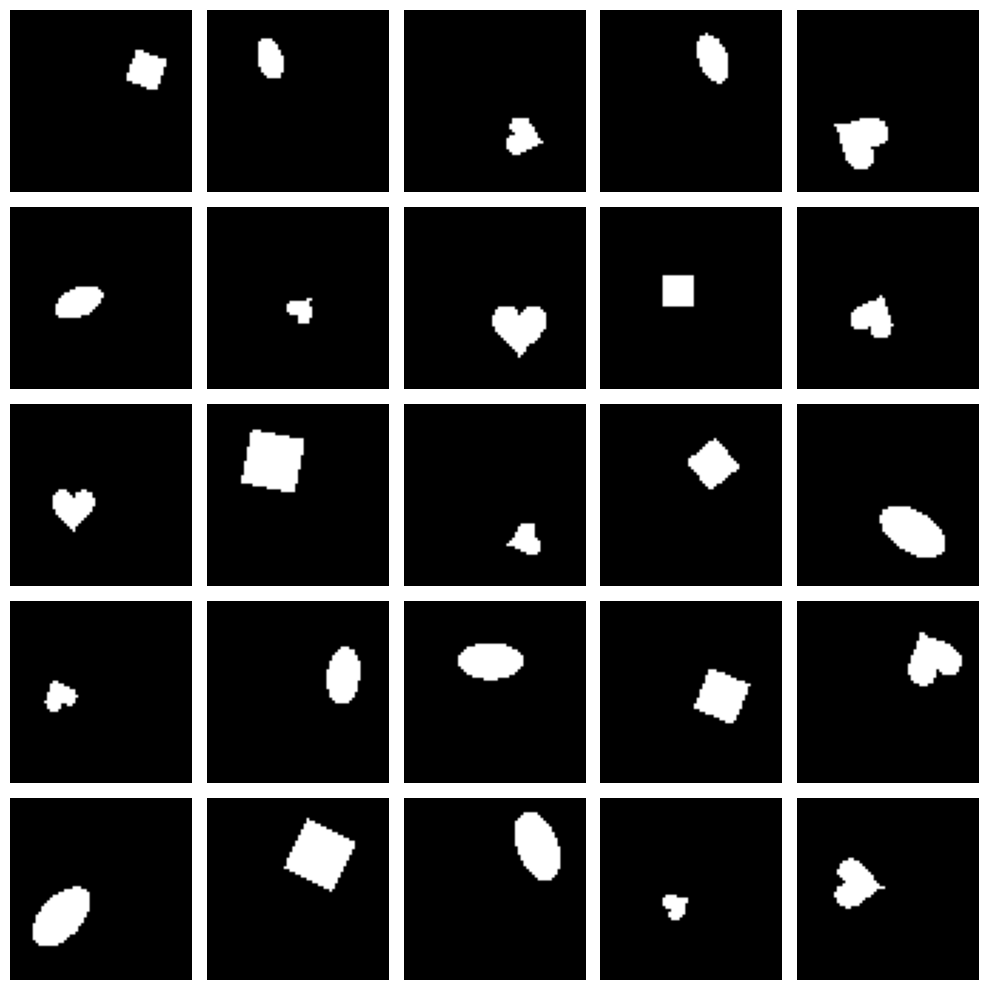

In [48]:
rng = np.random.RandomState(42)
indices = rng.choice(len(dataset['imgs']), 25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(dataset['imgs'][idx], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Scale x Orientation Heatmap

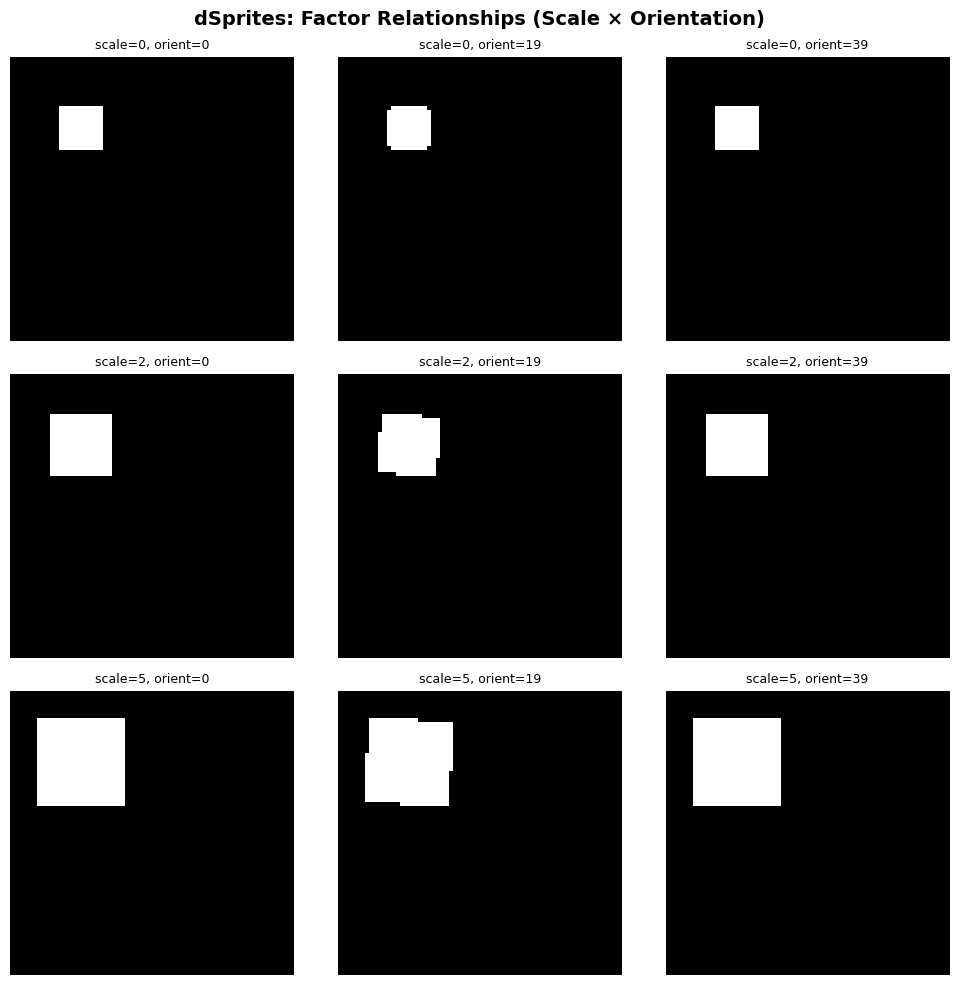

In [49]:
table = factor_pair_table(dataset, 'scale', 'orientation')

# Instead of showing counts (all balanced), show the actual factor relationship
# Visualize by plotting sample images that demonstrate scale×orientation correlation
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('dSprites: Factor Relationships (Scale × Orientation)', fontsize=14, fontweight='bold')

latents = dataset['latents_classes']
for i, scale_class in enumerate([0, 2, 5]):  # Small, medium, large
    for j, orient_class in enumerate([0, 19, 39]):  # Low, mid, high orientation
        ax = axes[i, j]
        # Find an image with these exact factors
        mask = (latents[:, 2] == scale_class) & (latents[:, 3] == orient_class)
        idx = np.where(mask)[0][0]
        ax.imshow(dataset['imgs'][idx], cmap='gray')
        ax.set_title(f'scale={scale_class}, orient={orient_class}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

## IID Split

Train: 516,095, Val: 110,592, Test: 110,593


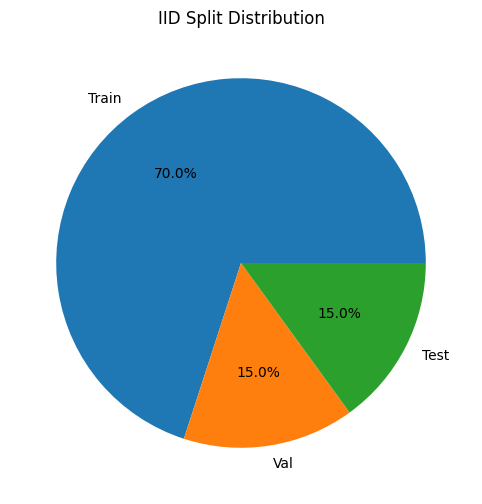

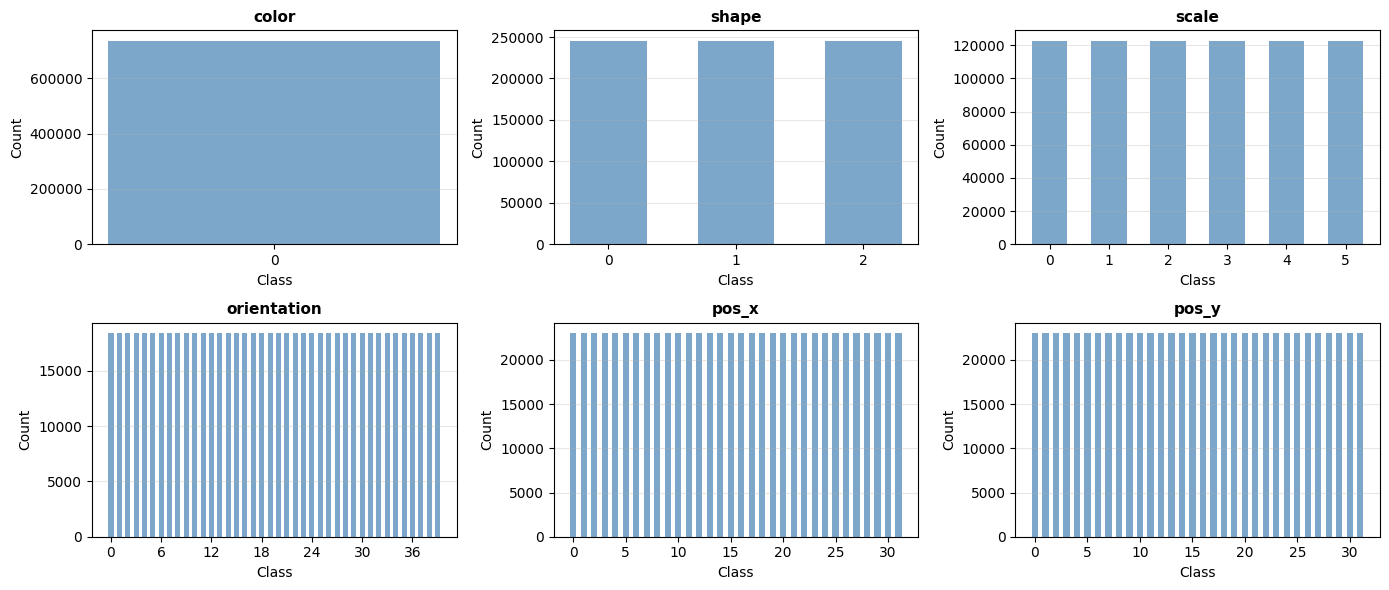

In [50]:
train_idx, val_idx, test_idx = make_iid_split(dataset)
print(f'Train: {len(train_idx):,}, Val: {len(val_idx):,}, Test: {len(test_idx):,}')
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie([len(train_idx), len(val_idx), len(test_idx)], labels=['Train', 'Val', 'Test'], autopct='%1.1f%%')
ax.set_title('IID Split Distribution')
plt.show()

# Factor marginals - FIXED
latents_classes = dataset['latents_classes']
factor_names = get_factor_names()
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, name in enumerate(factor_names):
    ax = axes[i // 3, i % 3]
    counts = np.bincount(latents_classes[:, i])
    classes = np.arange(len(counts))
    ax.bar(classes, counts, color='steelblue', alpha=0.7, width=0.6)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_xticks(classes[::max(1, len(classes)//6)])  # Reduce x-tick clutter
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Interactive Factor Explorer: Adjust Sliders to Browse Images

In [ ]:
train, val, test = make_correlated_split(dataset, 'scale', 'orientation', seed=42)
print(f'Correlated Split: Train={len(train):,}, Val={len(val):,}, Test={len(test):,}')

latents_values = dataset['latents_values']
scale_vals = latents_values[:, 2]  # Continuous scale
orient_vals = latents_values[:, 3]  # Continuous orientation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Train: concordant (positive correlation)
axes[0].scatter(scale_vals[train], orient_vals[train], alpha=0.4, s=8, color='#2ecc71')
axes[0].set_title('Train (Concordant):\nSmall→Low Orientation, Large→High Orientation', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Scale (continuous)')
axes[0].set_ylabel('Orientation (continuous)')
axes[0].grid(alpha=0.3)

# Val: mixed (no correlation)
axes[1].scatter(scale_vals[val], orient_vals[val], alpha=0.4, s=8, color='#3498db')
axes[1].set_title('Val (Mixed):\nIndependent Factors', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Scale (continuous)')
axes[1].set_ylabel('Orientation (continuous)')
axes[1].grid(alpha=0.3)

# Test: discordant or empty
if len(test) > 100:
    axes[2].scatter(scale_vals[test], orient_vals[test], alpha=0.4, s=8, color='#e74c3c')
    axes[2].set_title('Test (Discordant):\nLarge→Low Orientation, Small→High Orientation', fontsize=11, fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'Test is empty\n(all concordant pairs in train)', 
                ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title('Test (Empty)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Scale (continuous)')
axes[2].set_ylabel('Orientation (continuous)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation
if len(train) > 0:
    corr = np.corrcoef(scale_vals[train], orient_vals[train])[0, 1]
    print(f'✓ Correlation in training: {corr:.3f} (strong positive)')
    print(f'  → VAE must learn: do latents entangle or disentangle this correlation?')

## Held-Out Pair Split

In [ ]:
train_h, val_h, test_h, held = make_heldout_pair_split(dataset, 'shape', 'scale', [2], [4, 5], seed=42)
print(f'Train: {len(train_h):,}, Val: {len(val_h):,}, Test: {len(test_h):,}, Held-out: {len(held):,}')
print('✓ All splits created successfully!')